---
title: "Lab 2"
format:
    html:
        embed-resources: true
---

In [ ]:
# Question 0:

# I would use the papers with known authorship as training data and compare their writing styles to the disputed papers. After cleaning the text, I could use word frequencies or TF-IDF scores and cosine similarity to find which known papers each disputed paper is most similar to. I would then predict the author based on the most similar papers, while checking the method’s accuracy by testing it on known papers first.

In [ ]:
# Question 1:

import re
from collections import Counter
from urllib.request import urlopen

import pandas as pd

authorship = pd.read_csv(
    "https://dlsun.github.io/pods/data/federalist/authorship.csv"
)

papers = []

for paper_number in range(1, 86):
    url = f"https://dlsun.github.io/pods/data/federalist/{paper_number}.txt"
    
    with urlopen(url) as response:
        text = response.read().decode("utf-8")
    
    papers.append({
        "Paper": paper_number,
        "text": text
    })

papers = pd.DataFrame(papers)

papers["words"] = papers["text"].apply(
    lambda text: re.findall(r"\b[a-z]+\b", text.lower())
)

all_words = [
    word
    for paper_words in papers["words"]
    for word in paper_words
]

top_50_words = [
    word
    for word, count in Counter(all_words).most_common(50)
]

term_frequency_df = pd.DataFrame(
    [
        {
            word: Counter(paper_words)[word]
            for word in top_50_words
        }
        for paper_words in papers["words"]
    ],
    index=papers["Paper"]
)

term_frequency_df

,the,of,to,and,in,a,be,that,it,is,...,at,if,than,them,one,any,no,those,can,constitution
Paper,,,,,,,,,,,,,,,,,,,,,
1,133,106,72,40,27,25,34,28,20,13,...,8,4,11,2,4,6,3,9,3,8
2,107,83,53,83,34,30,15,44,38,16,...,10,3,5,4,10,1,1,2,0,0
3,93,62,56,60,25,13,31,20,21,7,...,1,7,8,8,8,5,2,6,3,0
4,86,72,51,90,24,16,26,17,28,10,...,2,14,9,12,13,5,1,4,8,0
5,66,53,45,72,28,9,31,23,21,7,...,4,3,9,11,10,3,2,9,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,389,248,163,88,135,87,85,49,65,61,...,7,6,6,16,10,15,8,12,6,13
82,168,94,83,41,38,22,36,19,13,15,...,2,2,3,4,9,1,4,6,5,4
83,485,331,219,121,213,139,105,121,102,116,...,19,24,16,21,18,16,22,13,6,13


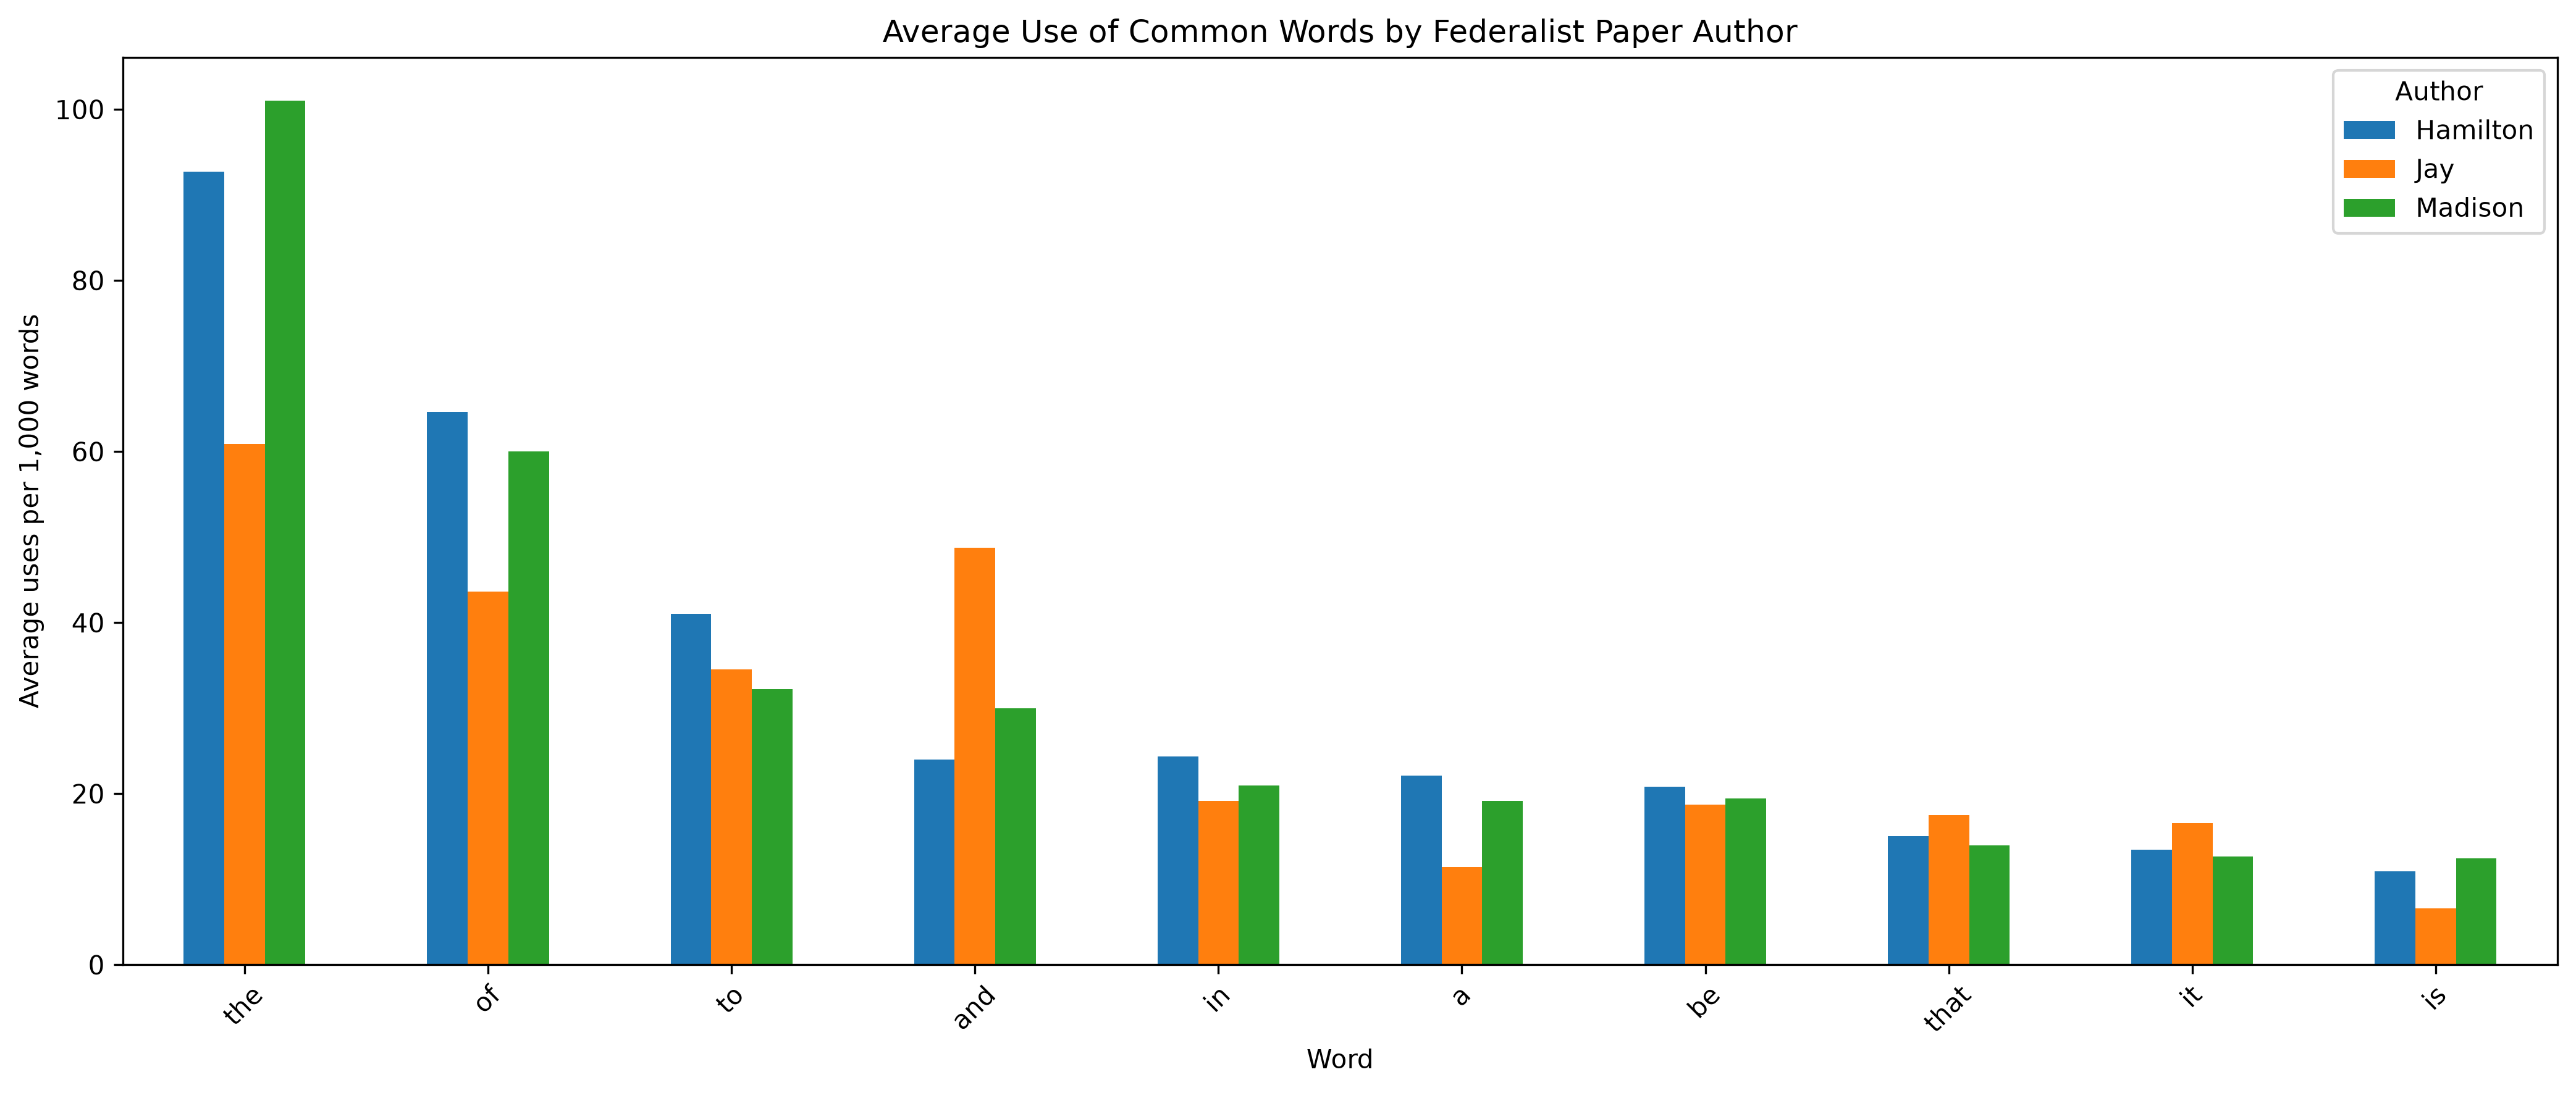

In [ ]:
# Question 2:

import matplotlib.pyplot as plt

author_map = authorship.set_index("Paper")["Author"]

term_frequency_with_authors = term_frequency_df.copy()
term_frequency_with_authors["Author"] = term_frequency_with_authors.index.map(author_map)

known_papers = term_frequency_with_authors.dropna(subset=["Author"])

paper_lengths = papers.set_index("Paper")["words"].apply(len)

for word in top_50_words:
    known_papers[word] = (
        known_papers[word] / known_papers.index.map(paper_lengths)
    ) * 1000

top_10_words = top_50_words[:10]

author_averages = known_papers.groupby("Author")[top_10_words].mean()

author_averages.T.plot(kind="bar", figsize=(14, 6))

plt.title("Average Use of Common Words by Federalist Paper Author")
plt.xlabel("Word")
plt.ylabel("Average uses per 1,000 words")
plt.xticks(rotation=45)
plt.legend(title="Author")
plt.tight_layout()
plt.show()

# The visualization compares how often Hamilton, Jay, and Madison used the most common words, after accounting for differences in paper length. Although all three authors use many of the same common words, their average frequencies differ for certain words. These differences in writing habits can help distinguish an author’s style and can be used to predict the authorship of the disputed papers.

In [ ]:
# Question 3:

# I would use the known papers as training data and compare each disputed paper’s common-word frequency vector to those of Hamilton, Jay, and Madison. For example, I could calculate cosine similarity and assign a disputed paper to the author whose known papers have the most similar writing-style pattern. I could also average each author’s term frequencies and classify each disputed paper based on which author average it is closest to.

In [6]:
# Question 4:

import math
from collections import Counter

tf_with_authors = term_frequency_df.copy()
tf_with_authors["Author"] = tf_with_authors.index.map(
    authorship.set_index("Paper")["Author"]
)

known_papers = tf_with_authors[tf_with_authors["Author"].notna()]
disputed_papers = tf_with_authors[tf_with_authors["Author"].isna()]

word_columns = top_50_words

def cosine_similarity(vector_1, vector_2):
    dot_product = sum(a * b for a, b in zip(vector_1, vector_2))
    
    magnitude_1 = math.sqrt(sum(a ** 2 for a in vector_1))
    magnitude_2 = math.sqrt(sum(b ** 2 for b in vector_2))
    
    return dot_product / (magnitude_1 * magnitude_2)

predictions = []

for disputed_paper, disputed_row in disputed_papers.iterrows():
    disputed_vector = disputed_row[word_columns].tolist()
    
    similarities = []
    
    for known_paper, known_row in known_papers.iterrows():
        known_vector = known_row[word_columns].tolist()
        
        similarity = cosine_similarity(disputed_vector, known_vector)
        
        similarities.append({
            "Known Paper": known_paper,
            "Author": known_row["Author"],
            "Cosine Similarity": similarity
        })
    
    five_closest = sorted(
        similarities,
        key=lambda row: row["Cosine Similarity"],
        reverse=True
    )[:5]
    
    predicted_author = Counter(
        row["Author"] for row in five_closest
    ).most_common(1)[0][0]
    
    predictions.append({
        "Disputed Paper": disputed_paper,
        "Predicted Author": predicted_author,
        "Five Closest Authors": [
            row["Author"] for row in five_closest
        ]
    })

predictions_df = pd.DataFrame(predictions)

predictions_df

for author in ["Hamilton", "Jay", "Madison"]:
    papers_by_author = predictions_df.loc[
        predictions_df["Predicted Author"] == author,
        "Disputed Paper"
    ].tolist()
    
    print(f"{author}: {papers_by_author}")

Hamilton: [49, 52, 55, 56]
Jay: []
Madison: [18, 19, 20, 50, 51, 53, 54, 57, 58, 62, 63]


In [7]:
# Question 5:

known_predictions = []

for target_paper, target_row in known_papers.iterrows():
    target_vector = target_row[word_columns].tolist()
    
    similarities = []
    
    for comparison_paper, comparison_row in known_papers.iterrows():
        
        if comparison_paper == target_paper:
            continue
        
        comparison_vector = comparison_row[word_columns].tolist()
        
        similarity = cosine_similarity(
            target_vector,
            comparison_vector
        )
        
        similarities.append({
            "Paper": comparison_paper,
            "Author": comparison_row["Author"],
            "Cosine Similarity": similarity
        })
    
    five_closest = sorted(
        similarities,
        key=lambda row: row["Cosine Similarity"],
        reverse=True
    )[:5]
    
    predicted_author = Counter(
        row["Author"] for row in five_closest
    ).most_common(1)[0][0]
    
    known_predictions.append({
        "Paper": target_paper,
        "Actual Author": target_row["Author"],
        "Predicted Author": predicted_author
    })

known_predictions_df = pd.DataFrame(known_predictions)

known_predictions_df

accuracy = (
    known_predictions_df["Actual Author"]
    == known_predictions_df["Predicted Author"]
).mean()

print(f"Accuracy: {accuracy:.1%}")

Accuracy: 95.7%


In [ ]:
# Question 6:

known_predictions_df["Correct"] = (
    known_predictions_df["Actual Author"]
    == known_predictions_df["Predicted Author"]
)

author_accuracy = (
    known_predictions_df
    .groupby("Actual Author")["Correct"]
    .mean()
    .reset_index()
)

author_accuracy["Proportion Correct"] = (
    author_accuracy["Correct"].round(3)
)

author_accuracy = author_accuracy[
    ["Actual Author", "Proportion Correct"]
]

author_accuracy

# The algorithm correctly predicted 100% of Hamilton’s papers, 60% of Jay’s papers, and 92.9% of Madison’s papers. Therefore, the method performs best for Hamilton and least accurately for Jay. Overall, the results suggest that common-word frequencies provide useful information about author style, although the algorithm does not perfectly distinguish all three authors.

,Actual Author,Proportion Correct
0,Hamilton,1.000
1,Jay,0.600
2,Madison,0.929


In [ ]:
# Question 7:

predicted_author_accuracy = (
    known_predictions_df
    .groupby("Predicted Author")["Correct"]
    .mean()
    .reset_index()
)

predicted_author_accuracy["Proportion Correct"] = (
    predicted_author_accuracy["Correct"].round(3)
)

predicted_author_accuracy = predicted_author_accuracy[
    ["Predicted Author", "Proportion Correct"]
]

predicted_author_accuracy

# Of the papers predicted to be written by Hamilton, 98.1% were actually written by Hamilton. For Jay, 100% of papers predicted as Jay were correct, while 86.7% of papers predicted as Madison were actually written by Madison. Overall, the algorithm’s predictions are very reliable, especially when it predicts Hamilton or Jay.

,Predicted Author,Proportion Correct
0,Hamilton,0.981
1,Jay,1.000
2,Madison,0.867
